# Evaluation: LLM Classification vs. Gold Standard

Five steps: Compliance → Accuracy (SPF F1, crisis_ref) → Krippendorff α → Confusion matrices → Factorial decomposition.

Run from the `4_analysis/` directory so that `step4_evaluate` is importable.

In [1]:
%matplotlib inline
import json
import sys
from datetime import date
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sys.path.insert(0, str(Path.cwd()))  # make step4_evaluate importable
from step4_evaluate import (
    CLASSIF_DIR, GOLD_PATH, RESULTS_DIR, DATASET_TAG, VALID_SPF, MIN_COMPLIANCE,
    PROMPT_WORD_COUNTS,
    load_gold, load_runs, _compliance_rate,
    step1_compliance, compliance_diagnosis,
    step2_accuracy, step3_alpha,
    step4_confusion, step5_factorial,
    jaccard_bucket_table,
)

TODAY = date.today().isoformat()

RESULTS_DIR.mkdir(parents=True, exist_ok=True)
(RESULTS_DIR / 'plots').mkdir(exist_ok=True)

gold     = load_gold(GOLD_PATH)
runs     = load_runs(CLASSIF_DIR)
gold_ids = list(gold.keys())

print(f'Gold standard entries : {len(gold_ids)}')
print(f'Classification runs   : {len(runs)}')
print(f'Partial runs          : {sum(r["is_partial"] for r in runs)}')
print('Models:', sorted({r['model'] for r in runs}))
print(f'\nDataset tag           : {DATASET_TAG}')
print(f'Today                 : {TODAY}')
print(f'\nCompliance threshold  : {MIN_COMPLIANCE}')
masked = [(r['model'], r['prompt_key']) for r in runs if _compliance_rate(r, gold_ids) < MIN_COMPLIANCE]
print(f'Runs masked in steps 2-5 ({len(masked)}):')
for model, prompt in masked:
    print(f'  {model}  |  {prompt}')

Gold standard entries : 68
Classification runs   : 112
Partial runs          : 0
Models: ['gemma-4-31b-it', 'gpt-4.1-mini', 'llama-3.3-70b-instruct', 'meta-llama-3.1-8b-instruct', 'mistral-large-3-675b-instruct-2512', 'openai-gpt-oss-120b', 'qwen3.6-35b-a3b']

Dataset tag           : ger_2008-2015_2019-2022
Today                 : 2026-06-06

Compliance threshold  : 0.8
Runs masked in steps 2-5 (30):
  mistral-large-3-675b-instruct-2512  |  v1_zero_shot_batch_nodef_nojus
  mistral-large-3-675b-instruct-2512  |  v3_zero_shot_batch_def_nojus
  mistral-large-3-675b-instruct-2512  |  v4_zero_shot_single_def_nojus
  mistral-large-3-675b-instruct-2512  |  v5_zero_shot_batch_nodef_jus
  mistral-large-3-675b-instruct-2512  |  v7_zero_shot_batch_def_jus
  mistral-large-3-675b-instruct-2512  |  v8_zero_shot_single_def_jus
  qwen3.6-35b-a3b  |  v3_zero_shot_batch_def_nojus
  qwen3.6-35b-a3b  |  v4_zero_shot_single_def_nojus
  qwen3.6-35b-a3b  |  v7_zero_shot_batch_def_jus
  qwen3.6-35b-a3b  |  v8

## Step 1 — Compliance

Share of policies for which the LLM returned a parseable, schema-valid output: all required fields present, `social_policy_field_1/2` drawn from the valid category list, and (for batch prompts) `crisis_ref` in {0, 1}.

Per-model summary (across all prompts):


,mean,min,max
model,,,
gemma-4-31b-it,0.710,0.029,0.956
gpt-4.1-mini,0.956,0.956,0.956
llama-3.3-70b-instruct,0.546,0.000,0.912
meta-llama-3.1-8b-instruct,0.622,0.015,0.956
mistral-large-3-675b-instruct-2512,0.678,0.000,0.956
openai-gpt-oss-120b,0.832,0.397,0.956
qwen3.6-35b-a3b,0.704,0.000,0.956


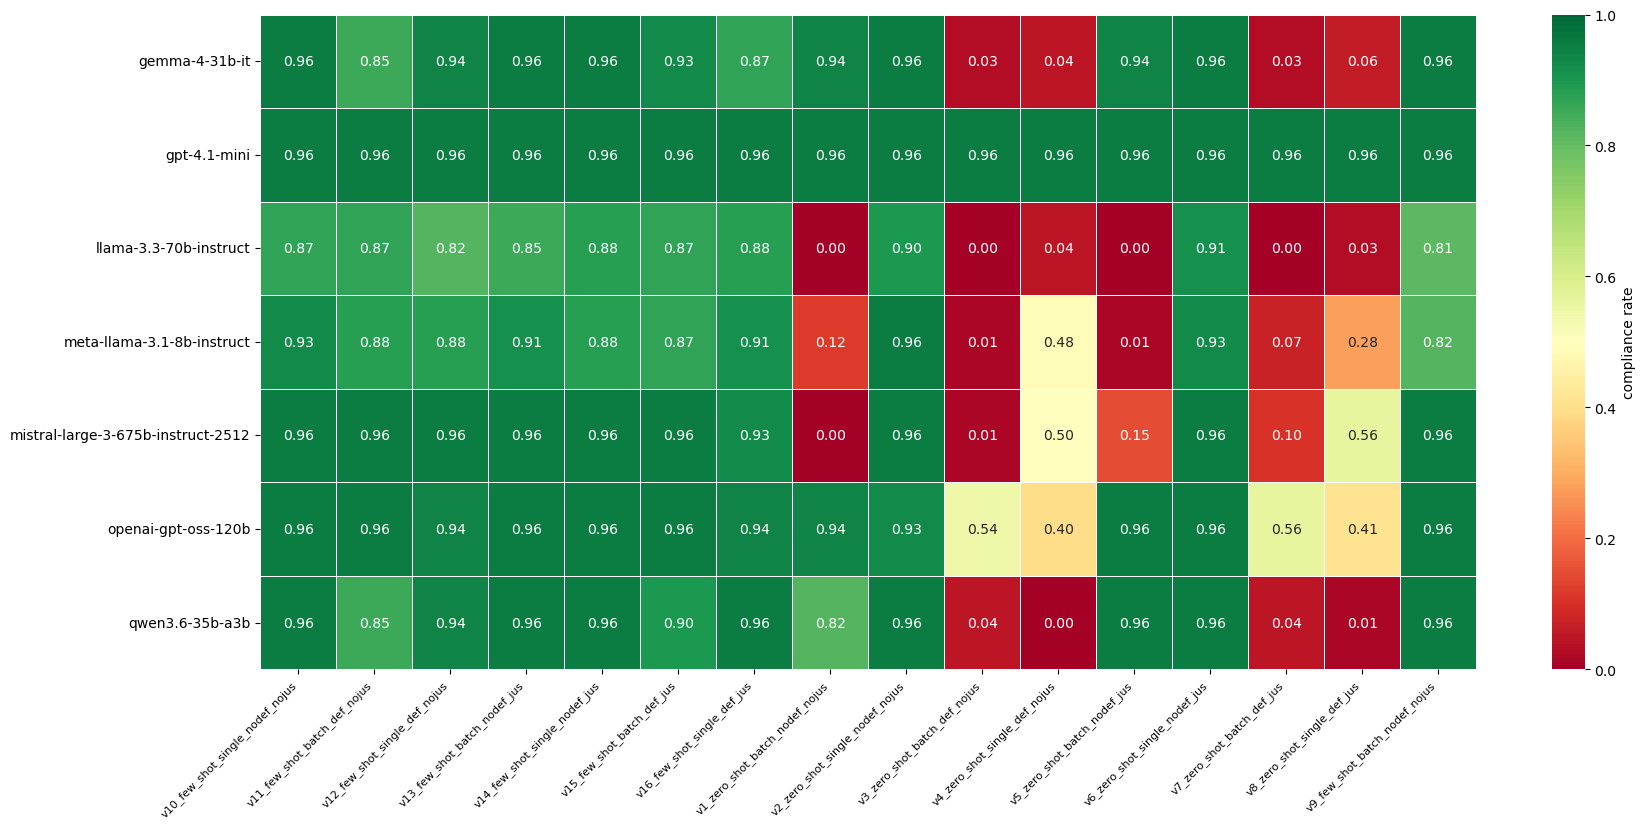

In [2]:
heatmap, summary = step1_compliance(runs, gold_ids)
heatmap.to_csv(RESULTS_DIR / 'compliance_heatmap.csv')
summary.to_csv(RESULTS_DIR / 'compliance_summary.csv')

print('Per-model summary (across all prompts):')
display(summary)

fig, ax = plt.subplots(figsize=(18, max(3, len(heatmap) * 1.2)))
sns.heatmap(
    heatmap, annot=True, fmt='.2f', cmap='RdYlGn', vmin=0, vmax=1,
    linewidths=0.4, ax=ax,
    cbar_kws={'label': 'compliance rate'},
)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'plots' / f'compliance_heatmap_{DATASET_TAG}_{TODAY}.png', dpi=150, bbox_inches='tight')
plt.show()

### Step 1.2 — Compliance diagnosis: what went wrong exactly?

Only runs with compliance < 0.70 are shown. For each flagged run, a stacked bar shows what fraction of policies triggered each failure check. Rates are **marginal and independent** — a single policy may contribute to multiple failure categories, so bars can sum to more than (1 − compliance).

30 run(s) with compliance < 70%


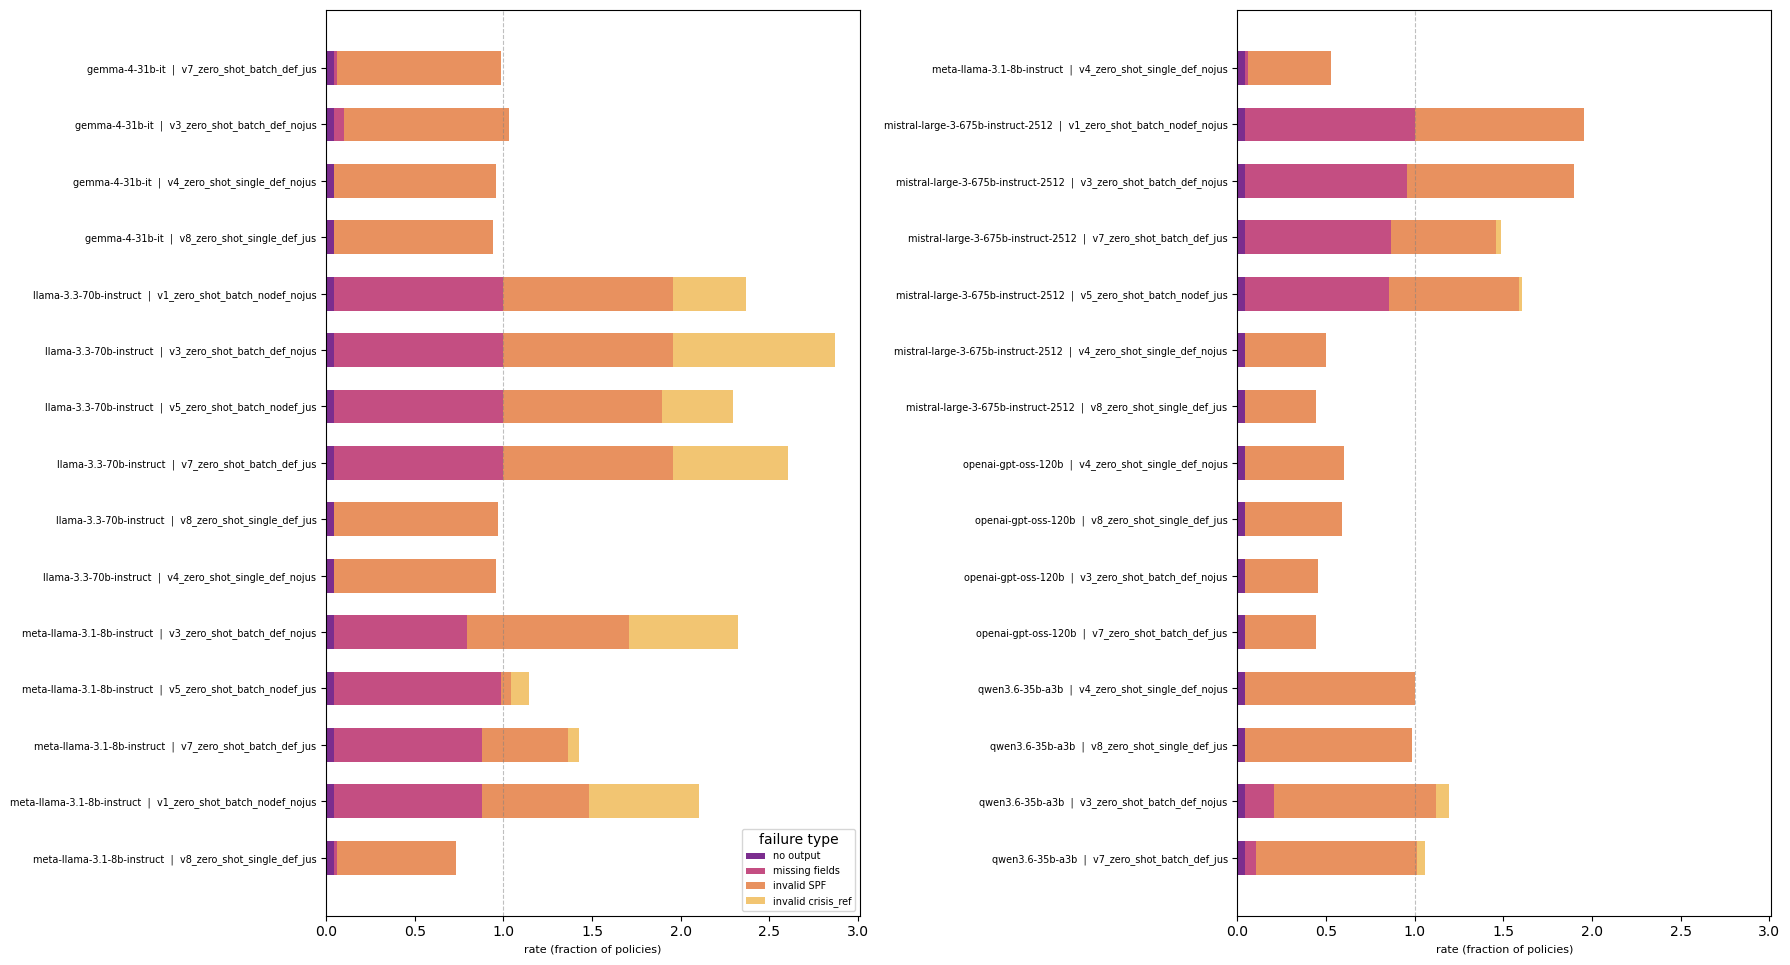

In [3]:
DIAG_THRESHOLD = 0.70

diag = compliance_diagnosis(runs, gold_ids, threshold=DIAG_THRESHOLD)

if diag.empty:
    print(f'All runs have compliance ≥ {DIAG_THRESHOLD:.0%} — nothing to diagnose.')
else:
    n_flagged = len(diag)
    print(f'{n_flagged} run(s) with compliance < {DIAG_THRESHOLD:.0%}')

    # re-sort: group by model alphabetically, worst-first within each model
    diag = (
        diag.reset_index()
        .sort_values(['model', 'compliance'])
        .set_index(['model', 'prompt_key'])
    )

    failure_cols = ['no_output', 'missing_fields', 'invalid_spf', 'invalid_crisis_ref']
    col_labels   = ['no output', 'missing fields', 'invalid SPF', 'invalid crisis_ref']
    colors       = ['#7b2d8e', '#c44e82', '#e8915f', '#f2c572']

    row_labels = [f'{m}  |  {p}' for m, p in diag.index]
    plot_data  = diag[failure_cols].fillna(0).copy()
    plot_data.index   = row_labels
    plot_data.columns = col_labels

    # split into two panels (side by side) to keep the figure compact
    ncols  = min(2, n_flagged)
    mid    = (n_flagged + ncols - 1) // ncols
    splits = [plot_data.iloc[i * mid:(i + 1) * mid] for i in range(ncols)]
    splits = [s for s in splits if len(s) > 0]
    ncols  = len(splits)

    max_x  = max(plot_data.sum(axis=1).max() * 1.05, 1.05)
    n_rows = max(len(s) for s in splits)

    fig, axes = plt.subplots(1, ncols, figsize=(9 * ncols, max(3, n_rows * 0.55 + 1.5)))
    axes = np.atleast_1d(axes)

    for ax, part in zip(axes, splits):
        lefts = np.zeros(len(part))
        for col, color in zip(col_labels, colors):
            vals = part[col].values
            ax.barh(range(len(part)), vals, left=lefts, color=color, label=col, height=0.6)
            lefts += vals
        ax.set_yticks(range(len(part)))
        ax.set_yticklabels(part.index, fontsize=7)
        ax.invert_yaxis()
        ax.set_xlabel('rate (fraction of policies)', fontsize=8)
        ax.set_xlim(0, max_x)
        ax.axvline(1.0, color='grey', lw=0.8, linestyle='--', alpha=0.5)

    axes[0].legend(loc='lower right', fontsize=7, title='failure type')
    plt.tight_layout()
    fig.savefig(RESULTS_DIR / 'plots' / f'compliance_diagnosis_{DATASET_TAG}_{TODAY}.png', dpi=150, bbox_inches='tight')
    plt.show()

## Step 2 — Accuracy

In [4]:
acc = step2_accuracy(runs, gold)

macro_f1_df        = acc['macro_f1_df']
macro_prec_df      = acc['macro_prec_df']
macro_rec_df       = acc['macro_rec_df']
jaccard_buckets_df = acc['jaccard_buckets_df']
crisis_f1_df       = acc['crisis_f1_df']
per_cat_f1_df      = acc['per_cat_f1_df']
per_cat_prec_df    = acc['per_cat_prec_df']
per_cat_rec_df     = acc['per_cat_rec_df']

macro_f1_df.to_csv(RESULTS_DIR / 'spf_macro_f1.csv')
macro_prec_df.to_csv(RESULTS_DIR / 'spf_macro_precision.csv')
macro_rec_df.to_csv(RESULTS_DIR / 'spf_macro_recall.csv')
jaccard_buckets_df.to_csv(RESULTS_DIR / 'spf_jaccard_buckets.csv')
crisis_f1_df.to_csv(RESULTS_DIR / 'crisis_ref_f1.csv')
per_cat_f1_df.to_csv(RESULTS_DIR / 'spf_per_category_f1_best_prompt.csv')
per_cat_prec_df.to_csv(RESULTS_DIR / 'spf_per_category_precision_best_prompt.csv')
per_cat_rec_df.to_csv(RESULTS_DIR / 'spf_per_category_recall_best_prompt.csv')

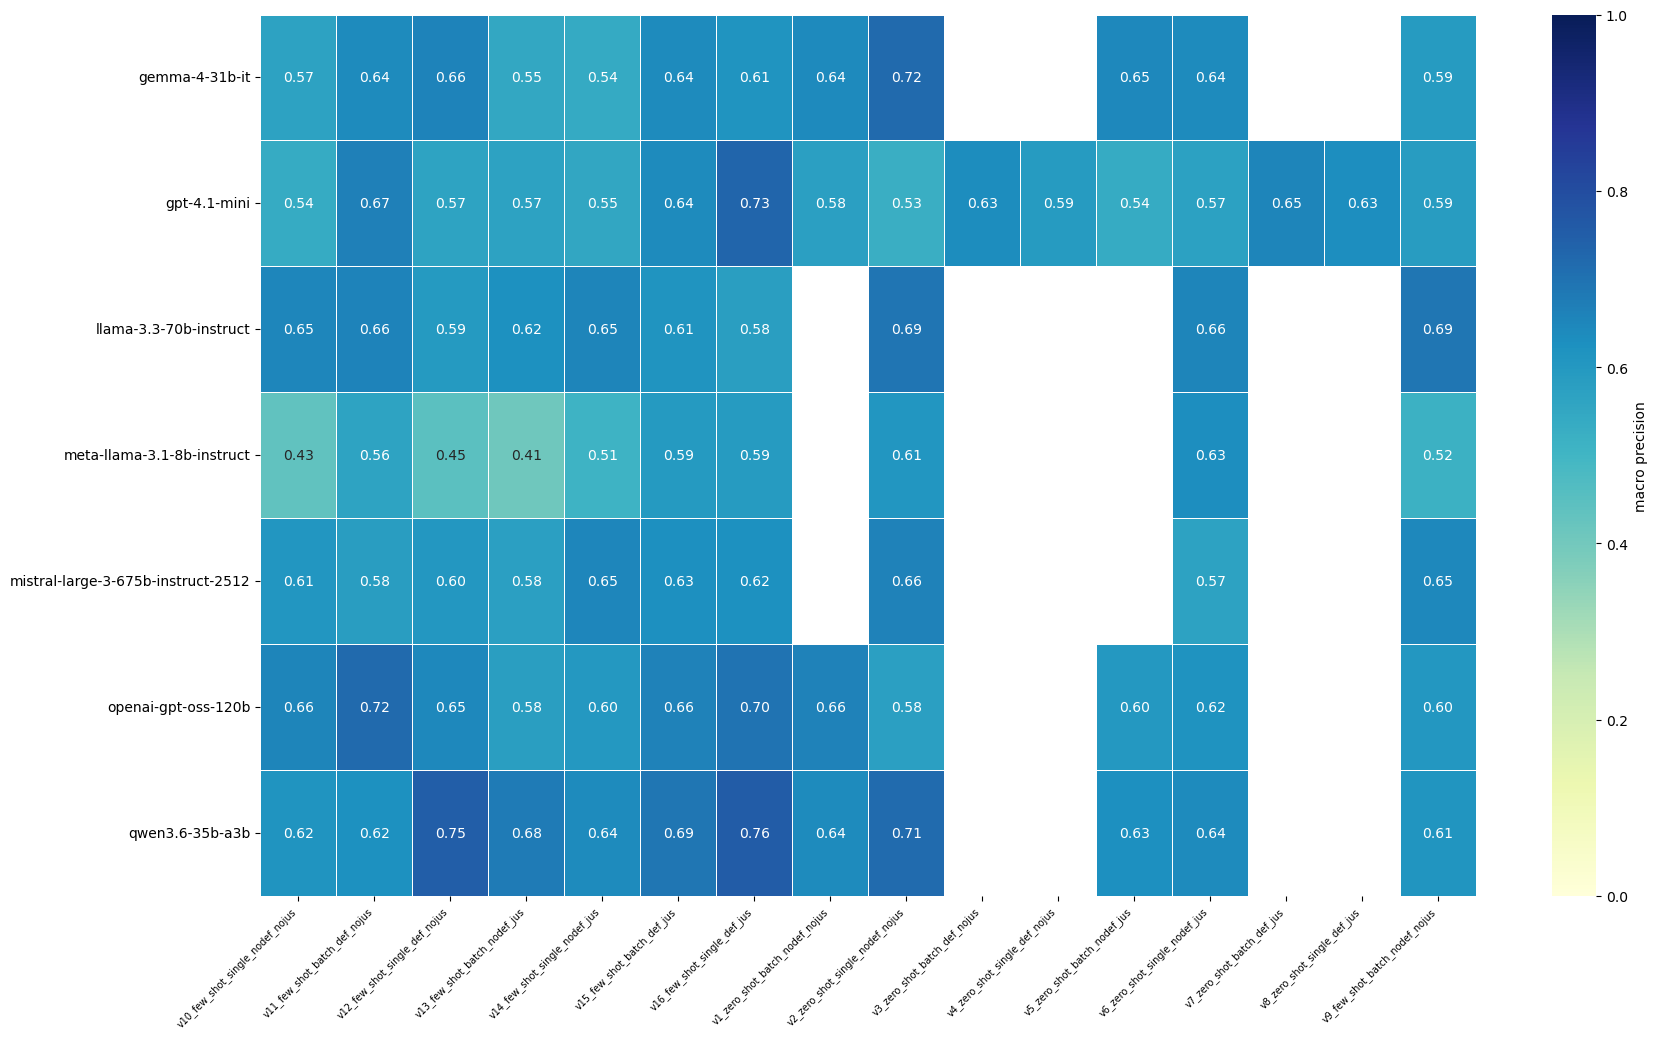

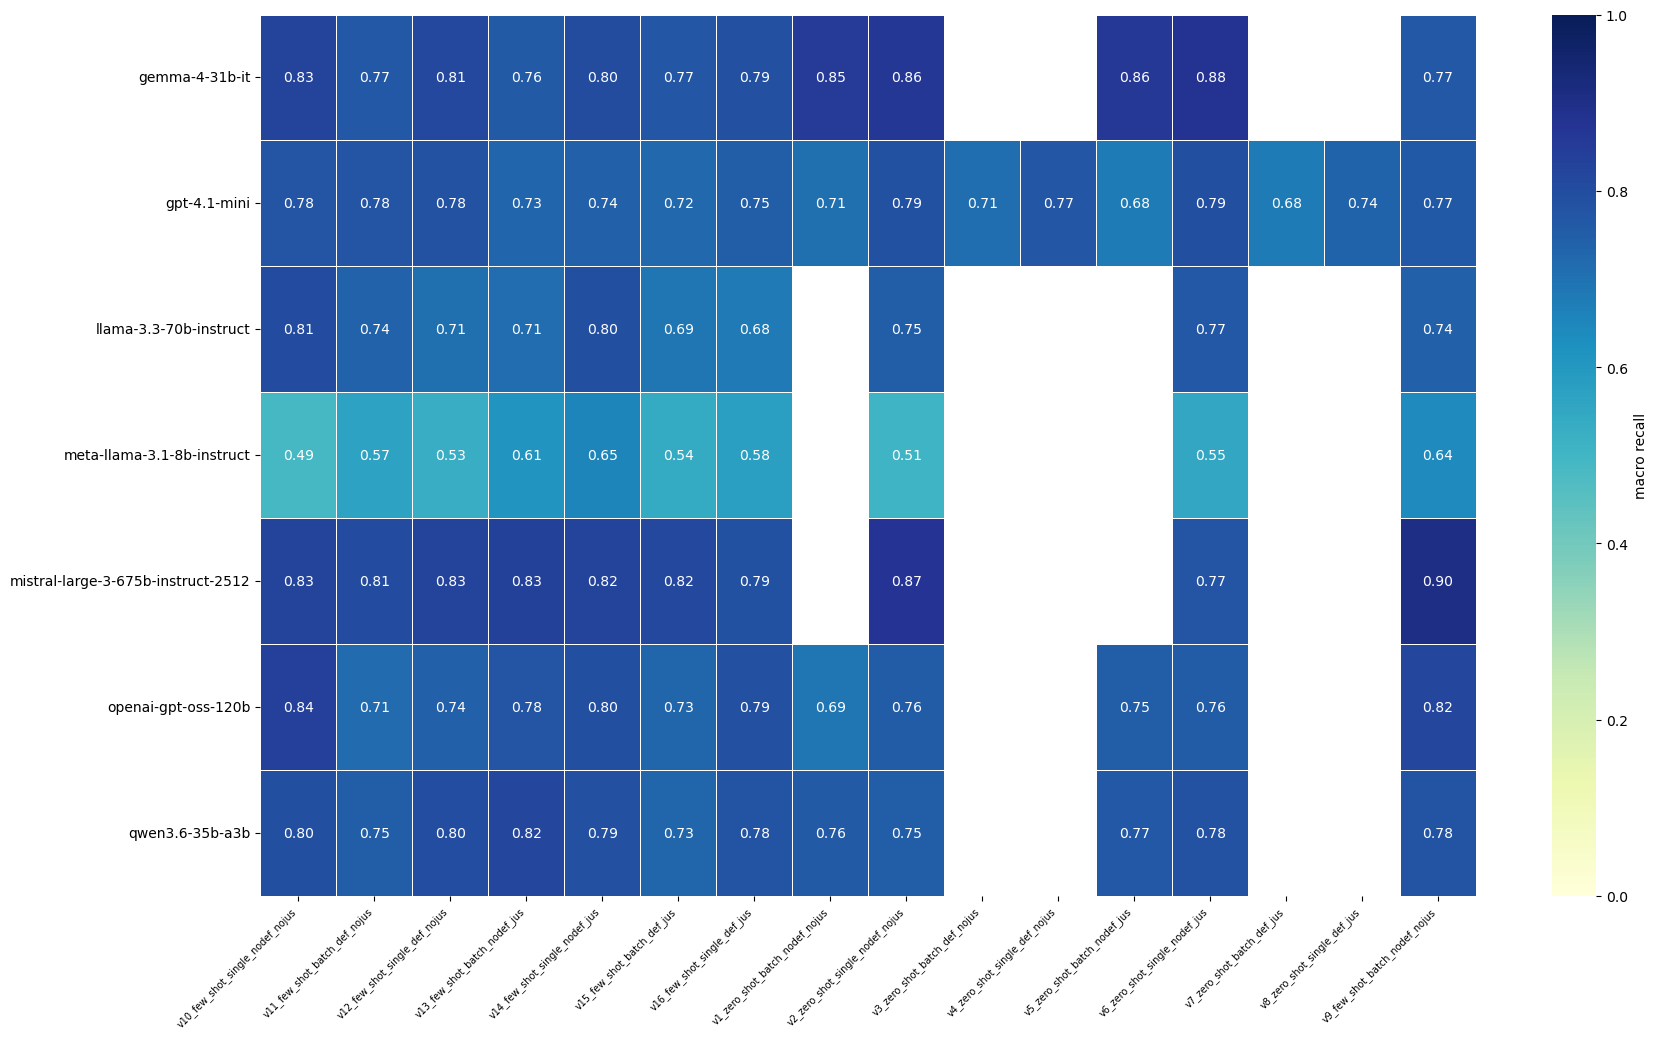

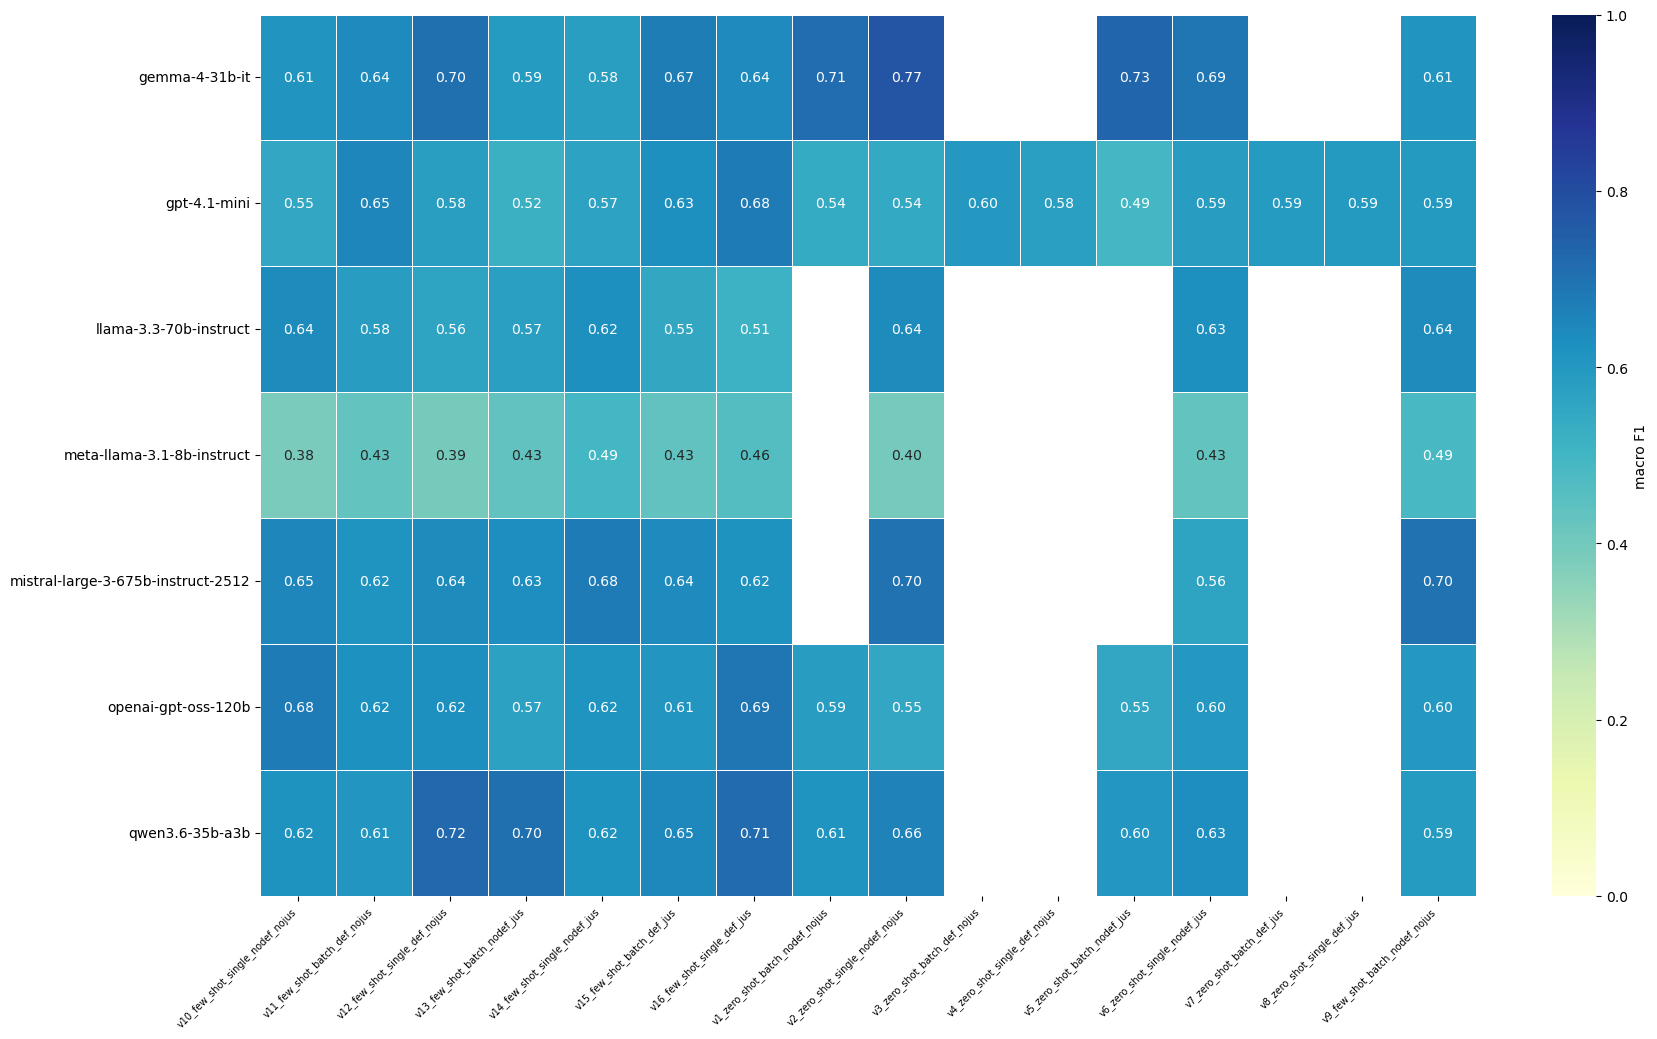

In [5]:
for df, fname, cbar_label in [
    (macro_prec_df, 'spf_accuracy_precision', 'macro precision'),
    (macro_rec_df,  'spf_accuracy_recall',    'macro recall'),
    (macro_f1_df,   'spf_accuracy_f1',        'macro F1'),
]:
    fig, ax = plt.subplots(figsize=(18, max(3, len(df) * 1.5)))
    sns.heatmap(
        df, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1,
        linewidths=0.4, ax=ax,
        cbar_kws={'label': cbar_label},
    )
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    plt.tight_layout()
    fig.savefig(RESULTS_DIR / 'plots' / f'{fname}_{DATASET_TAG}_{TODAY}.png', dpi=150, bbox_inches='tight')
    plt.show()

In [7]:
# ── Jaccard bucket distribution — best prompt per model ──────────────────────
jac_bkt = jaccard_bucket_table(macro_f1_df, runs, gold)
jac_bkt.to_csv(RESULTS_DIR / 'spf_jaccard_buckets_best_prompt.csv')

print('Jaccard similarity bucket distribution — best prompt per model:')
display(
    jac_bkt.style
    .format({
        'n_evaluated':             '{:.0f}',
        'exact_match':             '{:.0f}',
        'partial_overlap_1_2':     '{:.0f}',
        'partial_overlap_1_3':     '{:.0f}',
        'partial_overlap':         '{:.0f}',
        'no_overlap':              '{:.0f}',
        'exact_match_pct':         '{:.1f}%',
        'partial_overlap_1_2_pct': '{:.1f}%',
        'partial_overlap_1_3_pct': '{:.1f}%',
        'partial_overlap_pct':     '{:.1f}%',
        'no_overlap_pct':          '{:.1f}%',
    })
)

Jaccard similarity bucket distribution — best prompt per model:


,best_prompt,n_evaluated,exact_match,partial_overlap_1_2,partial_overlap_1_3,partial_overlap,no_overlap,exact_match_pct,partial_overlap_1_2_pct,partial_overlap_1_3_pct,partial_overlap_pct,no_overlap_pct
model,,,,,,,,,,,,
gemma-4-31b-it,v2_zero_shot_single_nodef_nojus,65,42,16,4,20,3,64.6%,24.6%,6.2%,30.8%,4.6%
gpt-4.1-mini,v16_few_shot_single_def_jus,65,46,8,1,9,10,70.8%,12.3%,1.5%,13.8%,15.4%
llama-3.3-70b-instruct,v10_few_shot_single_nodef_nojus,63,41,11,2,13,9,65.1%,17.5%,3.2%,20.6%,14.3%
meta-llama-3.1-8b-instruct,v14_few_shot_single_nodef_jus,62,29,17,2,19,14,46.8%,27.4%,3.2%,30.6%,22.6%
mistral-large-3-675b-instruct-2512,v2_zero_shot_single_nodef_nojus,65,45,13,3,16,4,69.2%,20.0%,4.6%,24.6%,6.2%
openai-gpt-oss-120b,v16_few_shot_single_def_jus,64,43,13,0,13,8,67.2%,20.3%,0.0%,20.3%,12.5%
qwen3.6-35b-a3b,v12_few_shot_single_def_nojus,64,52,3,2,5,7,81.2%,4.7%,3.1%,7.8%,10.9%


In [ ]:
print('Per-category F1 — best prompt per model:')
fig, ax = plt.subplots(figsize=(max(10, len(per_cat_f1_df.columns) * 1.5), max(3, len(per_cat_f1_df) * 1.2)))
sns.heatmap(
    per_cat_f1_df, annot=True, fmt='.2f', cmap='YlGnBu', vmin=0, vmax=1,
    linewidths=0.4, ax=ax,
)
ax.set_title('Per-category F1 — best prompt per model')
ax.set_xlabel('')
ax.set_ylabel('')
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'plots' / f'spf_per_category_f1_heatmap_{DATASET_TAG}_{TODAY}.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print('Per-category Precision — best prompt per model:')
display(per_cat_prec_df.style.format('{:.2f}').background_gradient(cmap='YlGnBu', axis=None, vmin=0, vmax=1))

print('Per-category Recall — best prompt per model:')
display(per_cat_rec_df.style.format('{:.2f}').background_gradient(cmap='YlGnBu', axis=None, vmin=0, vmax=1))

print('Per-category F1 — best prompt per model:')
display(per_cat_f1_df.style.format('{:.2f}').background_gradient(cmap='YlGnBu', axis=None, vmin=0, vmax=1))

In [ ]:
# ── Per-field precision / recall bar chart — best prompt per model ───────────
n_models = len(per_cat_prec_df)
ncols    = min(n_models, 3)
nrows    = (n_models + ncols - 1) // ncols
fields   = list(per_cat_f1_df.columns)

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, max(5, len(fields) * 0.6) * nrows))
axes = np.array(axes).flatten()

palette = sns.color_palette('muted', 2)

for ax, (idx, _) in zip(axes, per_cat_prec_df.iterrows()):
    model, prompt_key = idx
    prec_vals = per_cat_prec_df.loc[idx].values.astype(float)
    rec_vals  = per_cat_rec_df.loc[idx].values.astype(float)

    y = np.arange(len(fields))
    h = 0.35

    ax.barh(y + h / 2, prec_vals, height=h, label='Precision', color=palette[0])
    ax.barh(y - h / 2, rec_vals,  height=h, label='Recall',    color=palette[1])
    ax.set_yticks(y)
    ax.set_yticklabels(fields, fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_xlabel('Score', fontsize=8)
    ax.set_title(model.replace('/', '\n') + f'\n({prompt_key})', fontsize=8)
    ax.axvline(0.5, color='gray', linewidth=0.5, linestyle='--')
    ax.legend(fontsize=8)

for ax in axes[n_models:]:
    ax.set_visible(False)

plt.suptitle('Per-field Precision vs Recall — best prompt per model', fontsize=10)
plt.tight_layout()
fig.savefig(RESULTS_DIR / 'plots' / f'spf_per_field_precision_recall_{DATASET_TAG}_{TODAY}.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Prompt length vs. macro F1 scatter plot ─────────────────────────────────
# Total prompt length = template word count + policy full_text word count.
# Policy text is the same for every prompt version, so we use the mean across
# the 68 gold standard entries as a per-call estimate.
_raw_gold   = json.loads(GOLD_PATH.read_text(encoding='utf-8'))
_mean_text_wc = int(np.mean([
    len(e['full_text'].split()) for e in _raw_gold if 'full_text' in e
]))
print(f'Mean policy text word count: {_mean_text_wc}')

_total_wc = {k: v + _mean_text_wc for k, v in PROMPT_WORD_COUNTS.items()}

f1_long = (
    macro_f1_df.reset_index()
    .melt(id_vars='model', var_name='prompt_key', value_name='macro_f1')
    .dropna(subset=['macro_f1'])
)
f1_long['word_count'] = f1_long['prompt_key'].map(_total_wc)
f1_long = f1_long.dropna(subset=['word_count'])

models  = sorted(f1_long['model'].unique())
palette = dict(zip(models, sns.color_palette('tab10', len(models))))

fig, ax = plt.subplots(figsize=(10, 6))
for model in models:
    sub = f1_long[f1_long['model'] == model]
    ax.scatter(sub['word_count'], sub['macro_f1'],
               color=palette[model], label=model, alpha=0.8, s=60, zorder=3)

ax.set_xlabel(f'Total prompt word count (template + mean policy text, n={len(_raw_gold)})')
ax.set_ylabel('Macro F1')
ax.set_title('Prompt length vs. Macro F1 (compliant runs only)')
ax.set_ylim(0, 1)
ax.grid(True, which='major', axis='y', alpha=0.25)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(fontsize=8, title='Model', bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'plots' / f'prompt_length_vs_f1_{DATASET_TAG}_{TODAY}.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 3 — Krippendorff's α

In [ ]:
alpha_spf_bin_df, alpha_spf_nom_df, alpha_cr_df = step3_alpha(runs, gold)

alpha_spf_bin_df.to_csv(RESULTS_DIR / 'alpha_spf_binary.csv')
alpha_spf_nom_df.to_csv(RESULTS_DIR / 'alpha_spf_nominal.csv')
alpha_cr_df.to_csv(RESULTS_DIR  / 'alpha_crisis_ref.csv')

fig, axes = plt.subplots(1, 3, figsize=(32, max(3, len(alpha_spf_bin_df) * 1.5)))

for ax, df, title in zip(
    axes,
    [alpha_spf_bin_df, alpha_spf_nom_df, alpha_cr_df],
    [
        'Krippendorff α — SPF binary (avg over 9 categories)',
        'Krippendorff α — SPF nominal (field_1 only)',
        'Krippendorff α — crisis_ref binary (batch only)',
    ],
):
    sns.heatmap(
        df, annot=True, fmt='.2f', cmap='RdYlGn', vmin=-1, vmax=1,
        center=0, linewidths=0.4, ax=ax,
    )
    ax.set_title(title, fontsize=9)
    ax.set_xlabel('')
    ax.set_ylabel('')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
fig.savefig(RESULTS_DIR / 'plots' / f'alpha_heatmaps_{DATASET_TAG}_{TODAY}.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4 — Confusion Matrices (best prompt per model)

In [ ]:
step4_confusion(macro_f1_df, runs, gold, RESULTS_DIR / 'plots', file_suffix=f'_{DATASET_TAG}_{TODAY}')

# Display the saved PNGs inline
from IPython.display import Image, display as ipy_display
for png in sorted((RESULTS_DIR / 'plots').glob(f'confusion_*_{DATASET_TAG}_{TODAY}.png')):
    print(png.stem)
    ipy_display(Image(filename=str(png)))